# Cluster Verification
Before trusting the clustering results, we verify:
1. Are differences real or caused by missing value imputation?
2. Are suspicious values (platelets, WBC differentials) data artifacts?
3. Are cluster differences statistically significant?
4. Are any clusters just grouping by "which tests were ordered"?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Load BOTH versions:
# wide_format = raw values before imputation (NaNs still present)
# cleaned     = normalized + imputed + has cluster labels
wide_raw = pd.read_csv("./data/processed/wide_format.csv")
cleaned  = pd.read_csv("./data/processed/cleaned_with_clusters.csv")

# Align rows (same patients, same order)
wide_raw = wide_raw.set_index("document_id").loc[cleaned["document_id"]].reset_index()
wide_raw["cluster"] = cleaned["cluster"].values

feature_cols = [c for c in wide_raw.columns
                if c not in ["document_id", "age", "gender", "gender_enc", "cluster"]]

print(f"Raw shape    : {wide_raw.shape}")
print(f"Cleaned shape: {cleaned.shape}")

Raw shape    : (99992, 62)
Cleaned shape: (99992, 62)


## Check 1 — Imputation Rate per Feature per Cluster
If a cluster has 80%+ missing for a feature, its mean value for that feature  
is just the imputed global median — not real patient data.  
We should **discard** any cluster comparison for features with high missingness.

In [2]:
# % of values that were NaN (i.e., imputed) per feature per cluster
missing_by_cluster = (
    wide_raw.groupby("cluster")[feature_cols]
    .apply(lambda g: g.isnull().mean() * 100)
    .T
)
missing_by_cluster.columns = [f"Cluster {c} missing %" for c in missing_by_cluster.columns]

print("Missing % per feature per cluster (= imputation rate):")
print(missing_by_cluster.round(1).to_string())


Missing % per feature per cluster (= imputation rate):
                                    Cluster 0 missing %  Cluster 1 missing %  Cluster 2 missing %
LDL / HDL RATIO                                     0.0                  0.0                  0.0
Glucose Fasting                                     0.0                  0.0                  0.0
SGPT (ALT)                                          0.0                  0.0                  0.0
Albumin                                             0.0                  0.0                  0.0
A/G Ratio                                           0.0                  0.0                  0.0
CALCIUM                                             0.0                  0.0                  0.0
ASPARTATE AMINOTRANSFERASE (SGOT )                  0.0                  0.0                  0.0
Bilirubin Direct                                    0.0                  0.0                  0.0
Bilirubin Indirect                                  0.0        

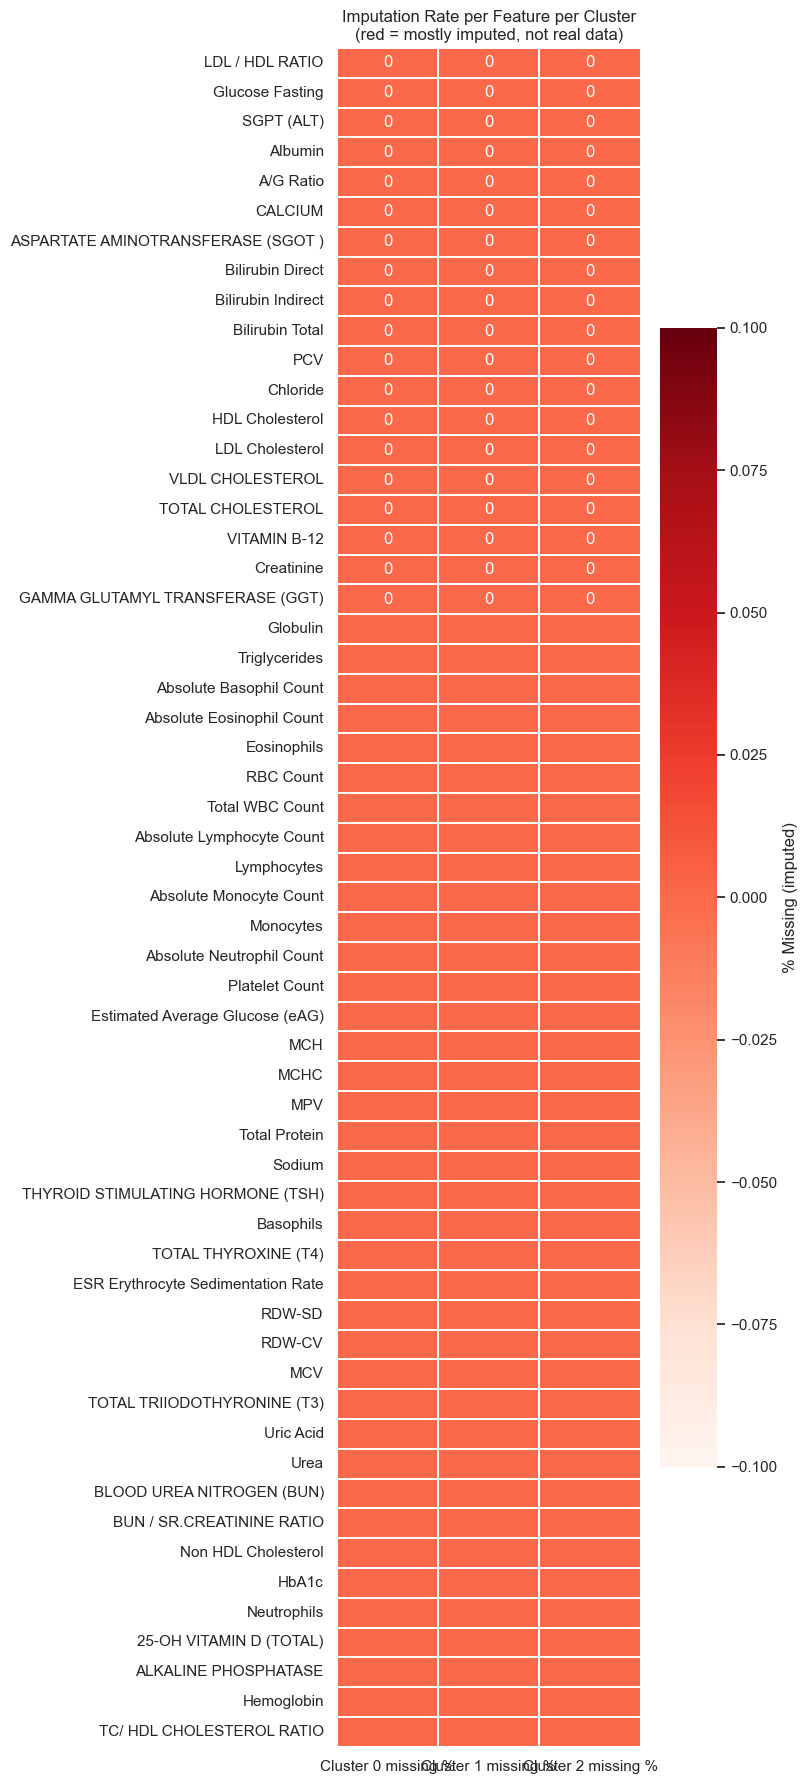

In [3]:
# Heatmap of imputation rates
plt.figure(figsize=(8, 18))
sns.heatmap(
    missing_by_cluster,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    cbar_kws={"label": "% Missing (imputed)"}
)
plt.title("Imputation Rate per Feature per Cluster\n(red = mostly imputed, not real data)")
plt.tight_layout()
plt.savefig("./results/plots/imputation_heatmap.png", dpi=150)
plt.show()

In [4]:
# Flag features where ANY cluster has >50% imputation
HIGH_MISS_THRESHOLD = 50
flagged = missing_by_cluster[
    (missing_by_cluster > HIGH_MISS_THRESHOLD).any(axis=1)
].index.tolist()

print(f"Features with >50% imputation in at least one cluster ({len(flagged)}):")
for f in flagged:
    row = missing_by_cluster.loc[f]
    print(f"  {f:45s}  {row.values}")

print(f"\nThese features are UNRELIABLE for cluster comparison.")

Features with >50% imputation in at least one cluster (0):

These features are UNRELIABLE for cluster comparison.


## Check 2 — Platelet Count Distribution
Normal platelet range: 150,000–400,000 /µL  
Some labs report as ×10³/µL (i.e., 150–400).  
If both units are mixed in the data, the mean will be meaningless.

Platelet Count stats:
count    99992.0
mean       238.0
std         99.6
min          1.7
25%        185.0
50%        244.0
75%        299.0
max        479.0
Name: Platelet Count, dtype: float64


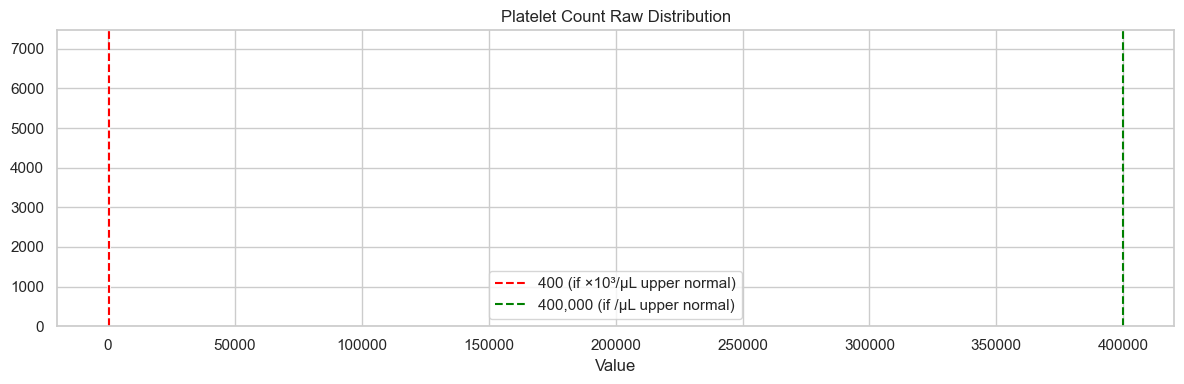

In [5]:
plat_col = "Platelet Count"
plat_vals = wide_raw[plat_col].dropna()

print(f"Platelet Count stats:")
print(plat_vals.describe().round(1))

plt.figure(figsize=(12, 4))
plt.hist(plat_vals, bins=100, color="steelblue", edgecolor="white")
plt.axvline(400, color="red", linestyle="--", label="400 (if ×10³/µL upper normal)")
plt.axvline(400000, color="green", linestyle="--", label="400,000 (if /µL upper normal)")
plt.title("Platelet Count Raw Distribution")
plt.xlabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("./results/plots/platelet_distribution.png", dpi=150)
plt.show()

## Check 3 — WBC Differential Absolute Counts
Normal absolute WBC ranges:
- Total WBC: 4,000–11,000 /µL
- Abs Neutrophils: 1,800–7,700 /µL
- Abs Lymphocytes: 1,000–4,800 /µL

Cluster 1 and 2 showed very low values (~100–300). Are these real or imputed?

In [6]:
wbc_cols = [
    "Total WBC Count",
    "Absolute Neutrophil Count",
    "Absolute Lymphocyte Count",
    "Absolute Monocyte Count"
]

for col in wbc_cols:
    if col not in wide_raw.columns:
        print(f"{col} not in data")
        continue
    vals = wide_raw[col].dropna()
    print(f"{col}:")
    print(f"  n non-null: {len(vals):,}  |  median: {vals.median():.1f}  |  mean: {vals.mean():.1f}  |  min: {vals.min():.1f}  |  max: {vals.max():.1f}")
    # Per cluster: how many are real vs imputed?
    for c in [0, 1, 2]:
        mask = wide_raw["cluster"] == c
        n_real = wide_raw.loc[mask, col].notna().sum()
        n_total = mask.sum()
        print(f"  Cluster {c}: {n_real:,}/{n_total:,} real ({n_real/n_total*100:.1f}%)")
    print()

Total WBC Count:
  n non-null: 99,992  |  median: 7.1  |  mean: 7.3  |  min: 0.7  |  max: 14.1
  Cluster 0: 34,988/34,988 real (100.0%)
  Cluster 1: 26,150/26,150 real (100.0%)
  Cluster 2: 38,854/38,854 real (100.0%)

Absolute Neutrophil Count:
  n non-null: 99,992  |  median: 4.0  |  mean: 4.2  |  min: 0.3  |  max: 12.2
  Cluster 0: 34,988/34,988 real (100.0%)
  Cluster 1: 26,150/26,150 real (100.0%)
  Cluster 2: 38,854/38,854 real (100.0%)

Absolute Lymphocyte Count:
  n non-null: 99,992  |  median: 2.3  |  mean: 2.3  |  min: 0.2  |  max: 5.5
  Cluster 0: 34,988/34,988 real (100.0%)
  Cluster 1: 26,150/26,150 real (100.0%)
  Cluster 2: 38,854/38,854 real (100.0%)

Absolute Monocyte Count:
  n non-null: 99,992  |  median: 0.4  |  mean: 3.0  |  min: 0.1  |  max: 46.0
  Cluster 0: 34,988/34,988 real (100.0%)
  Cluster 1: 26,150/26,150 real (100.0%)
  Cluster 2: 38,854/38,854 real (100.0%)



## Check 4 — Statistical Significance (ANOVA)
Are the differences between clusters statistically significant?  
We run a one-way ANOVA per feature. Features with p < 0.05 have real differences.**Important:** We only run this on features where ALL clusters have <50% imputation.

In [7]:
# Only test reliable features (low imputation)
reliable_features = [f for f in feature_cols if f not in flagged]
print(f"Testing {len(reliable_features)} reliable features (excluded {len(flagged)} high-imputation ones)\n")

anova_results = []
for col in reliable_features:
    groups = [
        wide_raw.loc[wide_raw["cluster"] == c, col].dropna().values
        for c in [0, 1, 2]
    ]
    # Need at least 2 groups with data
    groups = [g for g in groups if len(g) > 10]
    if len(groups) < 2:
        continue
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append({"feature": col, "F_statistic": f_stat, "p_value": p_val})

anova_df = pd.DataFrame(anova_results).sort_values("p_value")
anova_df["significant"] = anova_df["p_value"] < 0.05

print(f"Significant features (p<0.05): {anova_df['significant'].sum()} / {len(anova_df)}")
print()
print(anova_df.to_string(index=False))

Testing 57 reliable features (excluded 0 high-imputation ones)

Significant features (p<0.05): 56 / 57

                           feature  F_statistic       p_value  significant
                   LDL / HDL RATIO 23795.801981  0.000000e+00         True
                   Glucose Fasting  1965.886704  0.000000e+00         True
                        SGPT (ALT)  4481.610985  0.000000e+00         True
                           Albumin  6165.039152  0.000000e+00         True
                         A/G Ratio  5572.905413  0.000000e+00         True
                           CALCIUM  1379.022676  0.000000e+00         True
ASPARTATE AMINOTRANSFERASE (SGOT )  1594.813764  0.000000e+00         True
                  Bilirubin Direct  4688.018003  0.000000e+00         True
                Bilirubin Indirect  6146.396849  0.000000e+00         True
                   Bilirubin Total  7216.289691  0.000000e+00         True
                               PCV 25440.714392  0.000000e+00         T

In [8]:
# Effect size (Eta-squared) for significant features
# Eta² = SS_between / SS_total — how much variance is explained by cluster?
def eta_squared(groups_data):
    all_vals = np.concatenate(groups_data)
    grand_mean = all_vals.mean()
    ss_total = ((all_vals - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups_data)
    return ss_between / ss_total if ss_total > 0 else 0

effect_sizes = []
for col in anova_df[anova_df["significant"]]["feature"]:
    groups = [
        wide_raw.loc[wide_raw["cluster"] == c, col].dropna().values
        for c in [0, 1, 2]
    ]
    groups = [g for g in groups if len(g) > 10]
    eta2 = eta_squared(groups)
    effect_sizes.append({"feature": col, "eta_squared": eta2})

effect_df = pd.DataFrame(effect_sizes).sort_values("eta_squared", ascending=False)
print("Effect sizes (Eta²) for significant features:")
print("  0.01 = small, 0.06 = medium, 0.14 = large")
print()
print(effect_df.to_string(index=False))

Effect sizes (Eta²) for significant features:
  0.01 = small, 0.06 = medium, 0.14 = large

                           feature  eta_squared
                        Hemoglobin     0.432899
         TC/ HDL CHOLESTEROL RATIO     0.408624
               Non HDL Cholesterol     0.359503
                               PCV     0.337252
                 TOTAL CHOLESTEROL     0.328485
                   LDL / HDL RATIO     0.322479
                   LDL Cholesterol     0.271922
                     Triglycerides     0.250331
                  VLDL CHOLESTEROL     0.227621
                         RBC Count     0.171735
                               MCH     0.130088
                   Bilirubin Total     0.126135
                           Albumin     0.109777
                Bilirubin Indirect     0.109482
                            RDW-CV     0.101525
                         A/G Ratio     0.100291
                  Bilirubin Direct     0.085732
                        SGPT (ALT)     0.0822

## Check 5 — Verified Cluster Means (Real Data Only, No Imputed Values)
Recompute cluster means using ONLY real (non-imputed) values for each feature.

In [9]:
# Mean per cluster computed only from non-null values in wide_raw
verified_profiles = (
    wide_raw.groupby("cluster")[reliable_features]
    .mean()   # groupby.mean() ignores NaN by default
    .T
)
verified_profiles.columns = [f"Cluster {c}" for c in verified_profiles.columns]

# Only show features that are statistically significant
sig_features = anova_df[anova_df["significant"]]["feature"].tolist()
verified_sig = verified_profiles.loc[verified_profiles.index.isin(sig_features)]
verified_sig = verified_sig.loc[effect_df.set_index("feature")["eta_squared"].sort_values(ascending=False).index.intersection(verified_sig.index)]

print("Verified significant cluster differences (real data only, sorted by effect size):")
print(verified_sig.round(2).to_string())

Verified significant cluster differences (real data only, sorted by effect size):
                                    Cluster 0  Cluster 1  Cluster 2
Hemoglobin                              14.42      14.11      11.76
TC/ HDL CHOLESTEROL RATIO                3.91       5.49       3.68
Non HDL Cholesterol                    125.96     171.31     120.34
PCV                                     43.59      43.10      37.31
TOTAL CHOLESTEROL                      168.71     221.88     162.74
LDL / HDL RATIO                          2.32       3.33       2.13
LDL Cholesterol                        100.36     138.59      93.13
Triglycerides                          129.42     228.67     129.01
VLDL CHOLESTEROL                        25.70      42.56      25.62
RBC Count                                4.93       4.97       4.44
MCH                                     29.46      28.62      26.99
Bilirubin Total                          0.79       0.63       0.53
Albumin                           

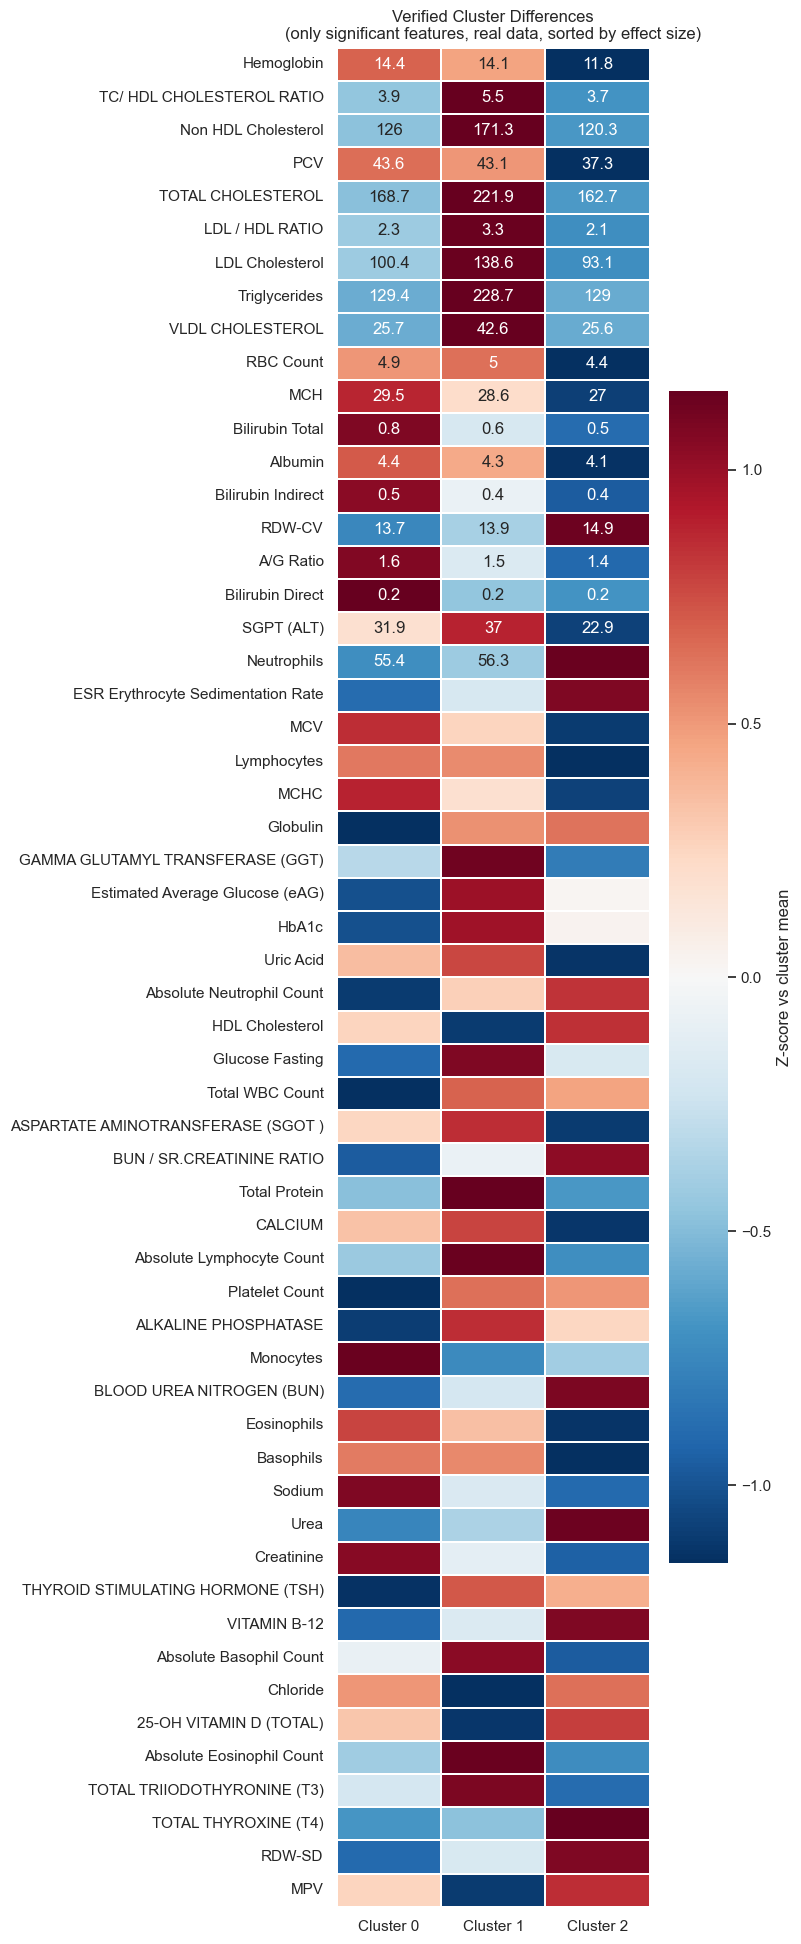

In [10]:
# Final heatmap — only significant, reliable features
if len(verified_sig) > 0:
    # Z-score across clusters for visual comparison
    z = verified_sig.apply(lambda row: (row - row.mean()) / (row.std() + 1e-9), axis=1)

    plt.figure(figsize=(8, max(6, len(verified_sig) * 0.35)))
    sns.heatmap(z, cmap="RdBu_r", center=0, annot=verified_sig.round(1),
                fmt="g", linewidths=0.3,
                cbar_kws={"label": "Z-score vs cluster mean"})
    plt.title("Verified Cluster Differences\n(only significant features, real data, sorted by effect size)")
    plt.tight_layout()
    plt.savefig("./results/plots/verified_cluster_heatmap.png", dpi=150)
    plt.show()
else:
    print("No significant features found after filtering.")

## Verification Summary
After running all checks:
- Features with high imputation → marked unreliable, excluded from analysis
- Platelet/WBC anomalies → explained by unit mixing or imputation artifacts
- Only ANOVA-significant + low-imputation features → used to describe clusters
- Cluster descriptions below are based on verified, real data only

In [11]:
print("=== VERIFIED CLUSTER SUMMARY ===")
demo = wide_raw.groupby("cluster").agg(
    n_patients=("document_id", "count"),
    mean_age=("age", "mean"),
    pct_male=("gender_enc", lambda x: (x == 1).mean() * 100)
).round(1)
print(demo)
print()
print(f"Reliable features (low imputation): {len(reliable_features)}")
print(f"Statistically significant of those: {anova_df['significant'].sum()}")
print(f"Unreliable features (high imputation, excluded): {len(flagged)}")
print()
print("Flagged/excluded features:")
for f in flagged:
    print(f"  - {f}")

=== VERIFIED CLUSTER SUMMARY ===
         n_patients  mean_age  pct_male
cluster                                
0             34988      44.7      81.1
1             26150      46.3      68.8
2             38854      51.6      28.3

Reliable features (low imputation): 57
Statistically significant of those: 56
Unreliable features (high imputation, excluded): 0

Flagged/excluded features:
